<a href="https://colab.research.google.com/github/alkhadrifuad/DataScience_250401020114_AlkhadriFuad/blob/master/Pertemuan9_alkhadrifuad_250401020114.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pemuatan Dataset

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


#Dataset ini memiliki 569 sampel dengan 30 fitur

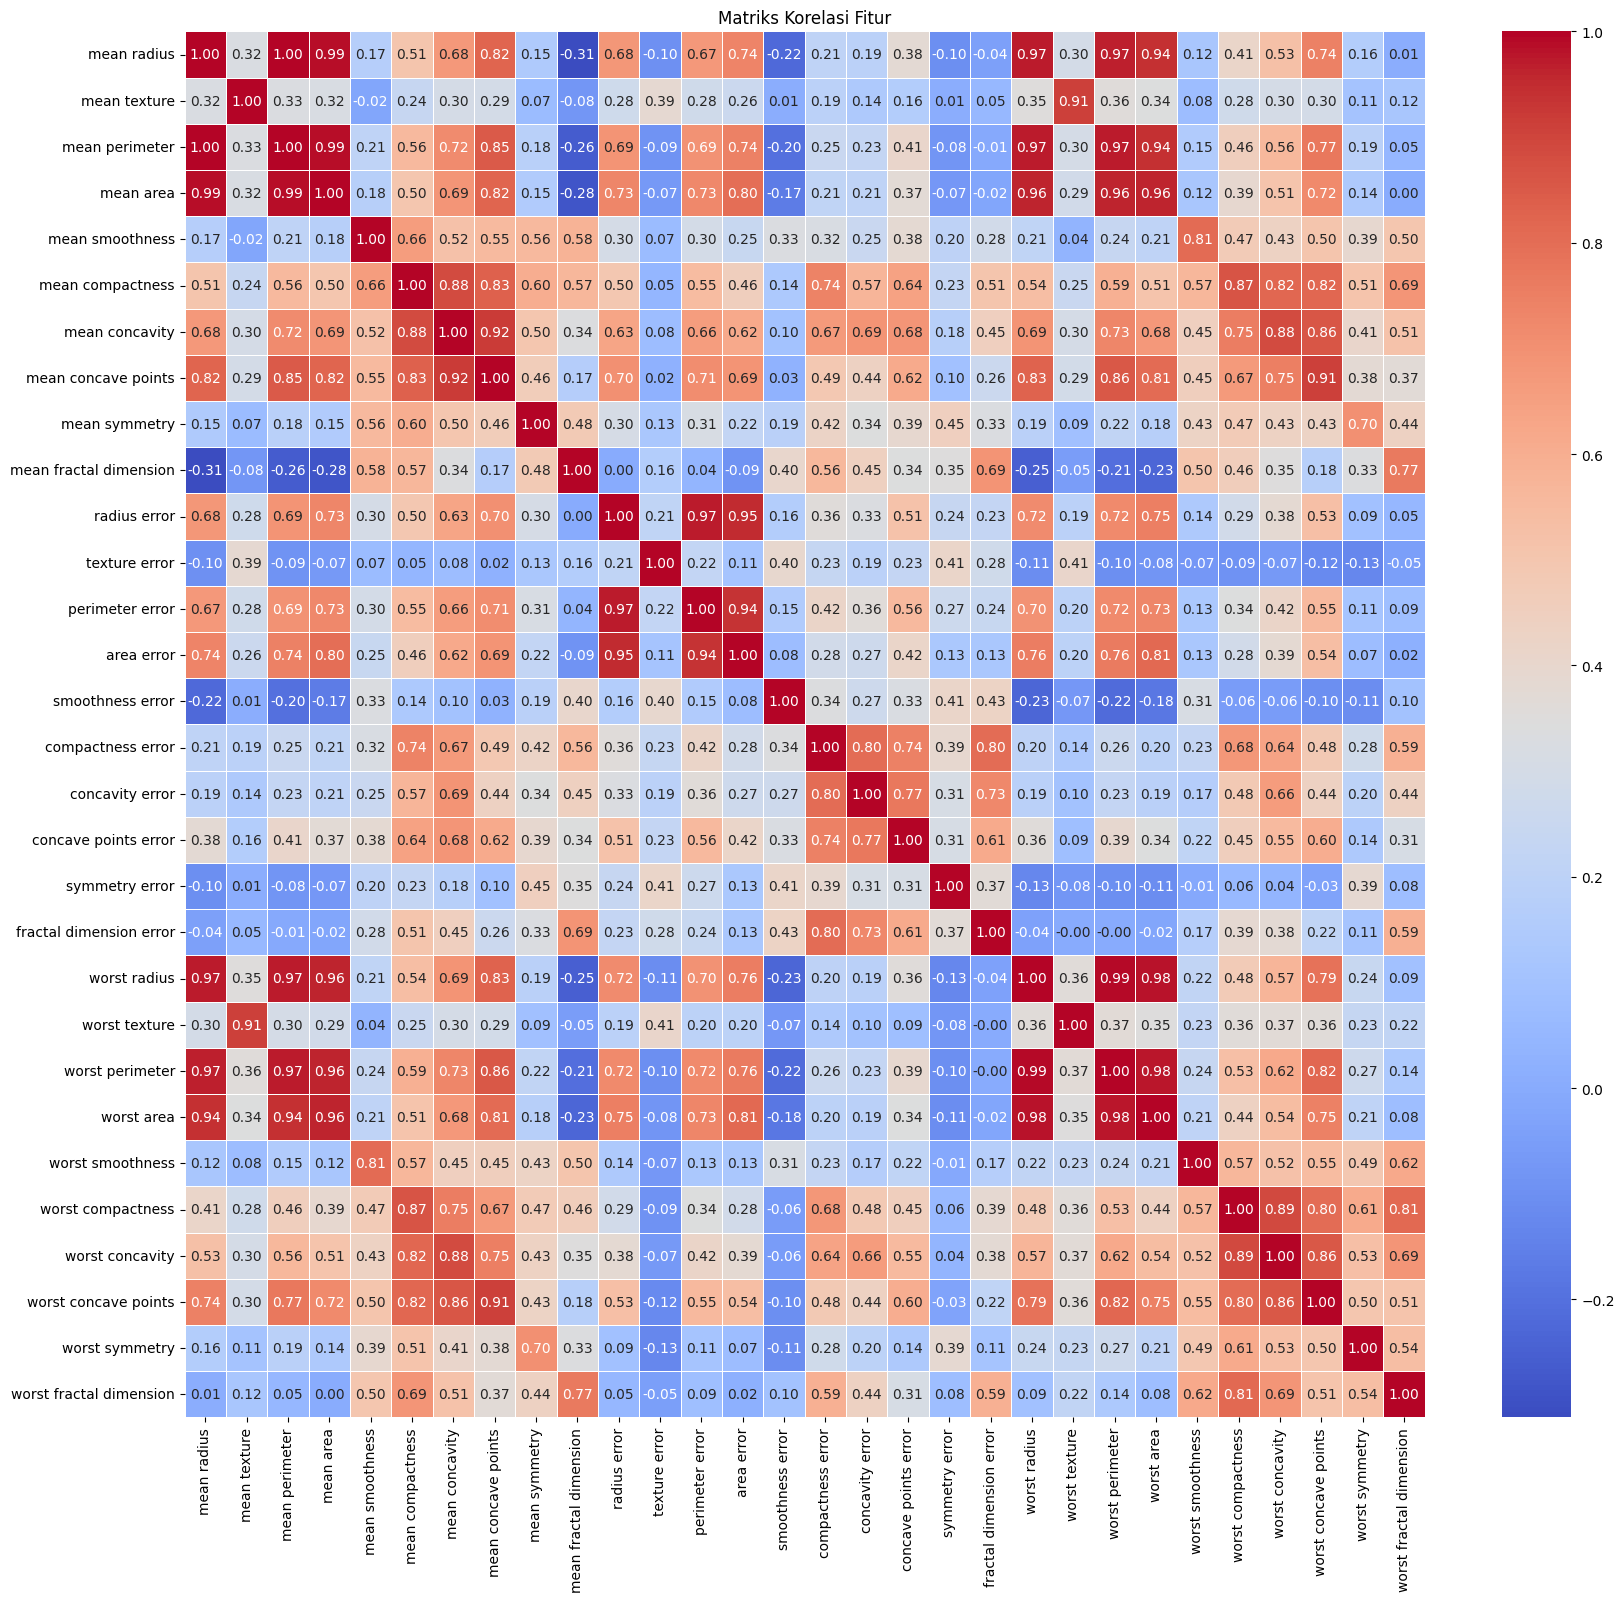

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung matriks korelasi
correlation_matrix = X.corr()

# Visualisasikan matriks korelasi dengan heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriks Korelasi Fitur')
plt.show()

## 2. Preprocessing Data

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data latih :", X_train.shape)
print("Data uji   :", X_test.shape)

Data latih : (455, 30)
Data uji   : (114, 30)


In [12]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Shape X_train_s (after scaling):', X_train_s.shape)
print('Shape X_test_s (after scaling):', X_test_s.shape)

Shape X_train_s (after scaling): (455, 30)
Shape X_test_s (after scaling): (114, 30)


memuat data kanker payudara, melakukan EDA awal yang menunjukkan 30 fitur dan multikolinearitas, serta mempramrosesan data dengan membaginya menjadi set latih dan uji (80/20 terstratifikasi) dan menskalakan fitur. Data sekarang siap untuk pelatihan model.

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.reindex(
    coef_df.Coefficient.abs().sort_values(ascending=False).index
)

coef_df.head(10)

,Feature,Coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

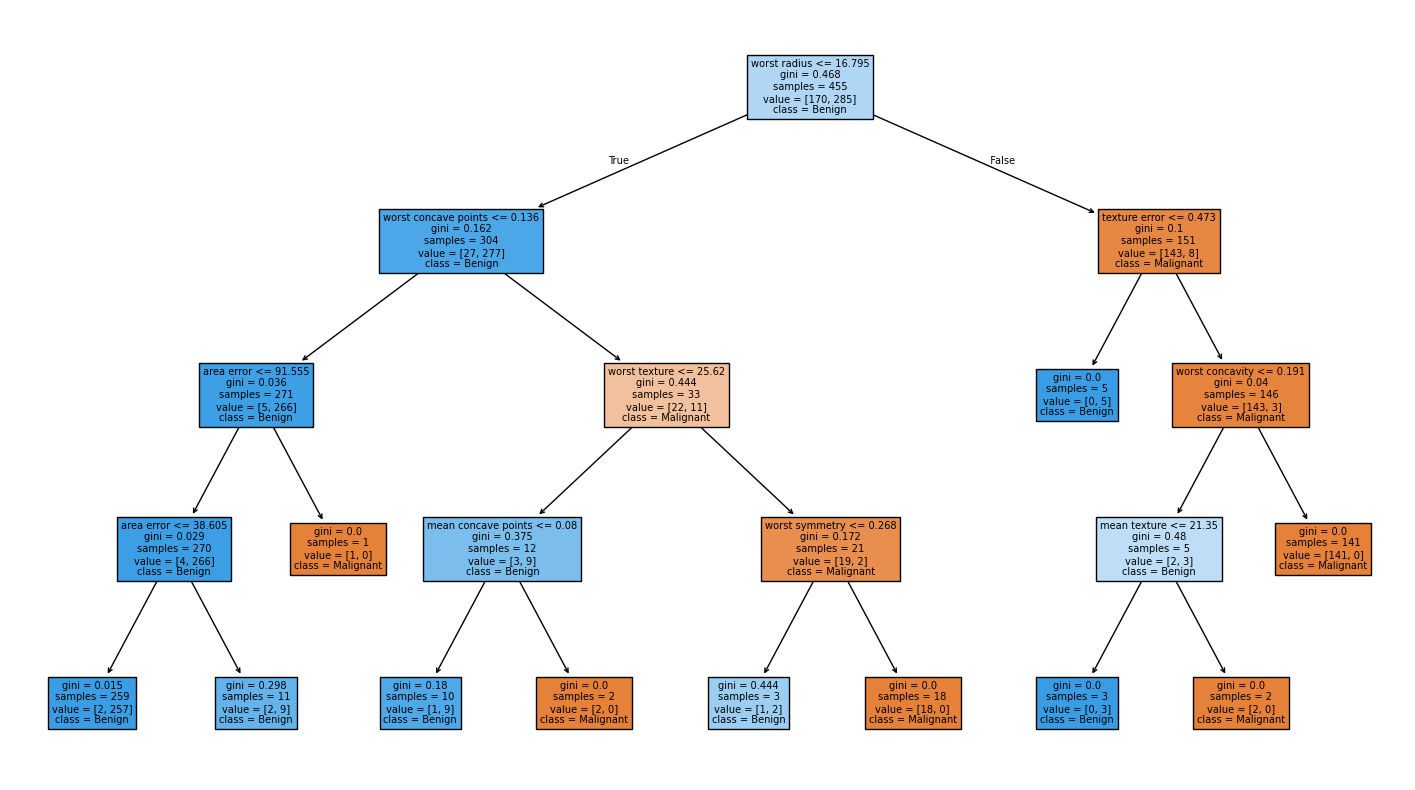

In [18]:
plt.figure(figsize=(18,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True
)

plt.show()

In [19]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree
}

for name, pred in models.items():

    print("="*50)
    print(name)
    print("="*50)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("Accuracy :", round(accuracy_score(y_test, pred),3))
    print("Precision:", round(precision_score(y_test, pred),3))
    print("Recall   :", round(recall_score(y_test, pred),3))
    print("F1 Score :", round(f1_score(y_test, pred),3))

Logistic Regression

Confusion Matrix
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1 Score : 0.986
Decision Tree

Confusion Matrix
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1 Score : 0.951


#analisis dan membangun model untuk mendeteksi kanker payudara:

Persiapan Data: Kami memuat data, menganalisis hubungan antar fitur (beberapa fitur sangat mirip), lalu membagi data menjadi dua bagian: untuk melatih model (80%) dan untuk menguji model (20%). Semua fitur juga sudah diseragamkan ukurannya agar model bisa bekerja lebih baik.

Model yang Digunakan: Kami mencoba dua jenis model:

#Regresi Logistik:
Model ini memberikan bobot ke setiap fitur untuk memprediksi hasil. Fitur-fitur seperti 'worst texture' dan 'radius error' sangat berpengaruh.
Pohon Keputusan: Model ini membuat serangkaian pertanyaan 'ya' atau 'tidak' untuk sampai pada keputusan, dan kami juga melihat visualisasi bagaimana keputusan itu dibuat.
Hasil dan Perbandingan: Kami membandingkan kedua model:

#Regresi Logistik:
Model ini menunjukkan hasil yang sangat bagus, hampir 98% akurat dalam memprediksi. Kesalahannya sangat sedikit.
Pohon Keputusan: Model ini juga bagus, sekitar 94% akurat, tapi masih sedikit di bawah Regresi Logistik.

#Kesimpulan:
 Dari analisis ini, model Regresi Logistik menunjukkan performa yang superior dalam mengklasifikasikan kanker payudara dibandingkan dengan model Pohon Keputusan yang dilatih. Ini didasarkan pada metrik evaluasi yang sangat tinggi di semua aspek, dengan jumlah kesalahan klasifikasi yang minimal. Langkah selanjutnya mungkin bisa meliputi penyetelan hyperparameter yang lebih lanjut atau eksplorasi metode pengurangan dimensi untuk mengatasi multikolinearitas yang teridentifikasi, yang berpotensi meningkatkan performa lebih lanjut